### EDA cont.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [17]:
da = pd.read_csv('cleaned_school_data_updated.csv')

In [18]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14467 entries, 0 to 14466
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Report Category       14467 non-null  object 
 1   DBN                   14467 non-null  object 
 2   school_name           14467 non-null  object 
 3   Grade                 14467 non-null  object 
 4   Year                  14467 non-null  int64  
 5   Student Category      14467 non-null  object 
 6   number_tested         14467 non-null  int64  
 7   mean_scale_score      14389 non-null  float64
 8   level_1_count         14389 non-null  float64
 9   level_1_percentage    14389 non-null  float64
 10  level_2_count         14389 non-null  float64
 11  level_2_percentage    14389 non-null  float64
 12  level_3_count         14389 non-null  float64
 13  level_3_percentage    14389 non-null  float64
 14  level_4_count         14389 non-null  float64
 15  level_4_percentage 

In [19]:
da_clean = da.dropna(subset=['% Poverty', 'mean_scale_score'])

In [20]:
da_clean['School Level'] = da_clean['Grade'].apply(lambda x: 'Elementary' if x in ['3','4','5'] else 'Middle')

C:\Users\madis\AppData\Local\Temp\ipykernel_42172\241498269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_clean['School Level'] = da_clean['Grade'].apply(lambda x: 'Elementary' if x in ['3','4','5'] else 'Middle')


In [21]:
da_clean = da_clean[da_clean['Grade'] != 'All Grades']


In [24]:
da_clean['poverty_clean'] = da_clean['% Poverty'] * 100

In [52]:
da_clean_2019 = da_clean[da_clean['Year'] == 2019]

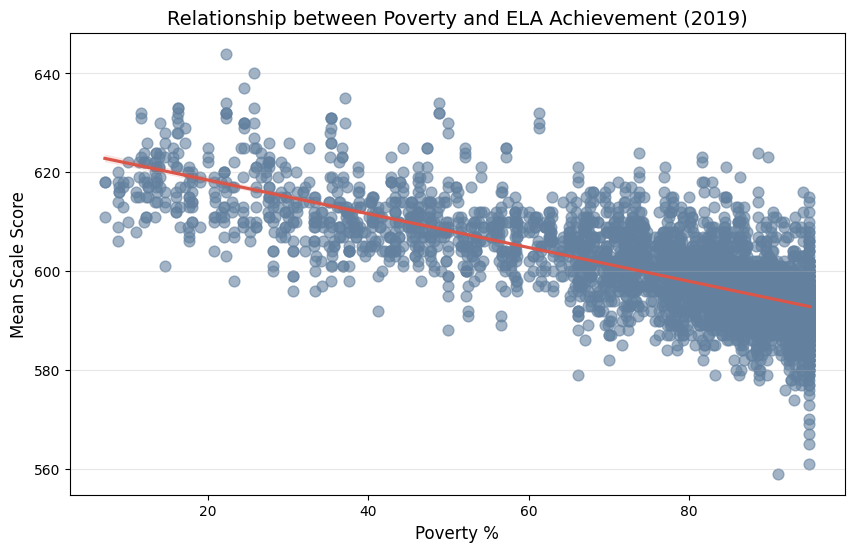

In [54]:



plt.figure(figsize=(10, 6))

sns.regplot(data=da_clean_2019, x='poverty_clean', y='mean_scale_score',
            scatter_kws={'color': "#63819f", 'alpha': 0.6, 's': 60},
            line_kws={'color': "#db5648"})


plt.title('Relationship between Poverty and ELA Achievement (2019)', fontsize=14)
plt.xlabel('Poverty %', fontsize=12)
plt.ylabel('Mean Scale Score', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [26]:
da_clean

,Report Category,DBN,school_name,Grade,Year,Student Category,number_tested,mean_scale_score,level_1_count,level_1_percentage,...,level_3_count,level_3_percentage,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty,Poverty_Category,School Level,poverty_clean
0,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2022,All Students,21,594.0,4.0,19.0,...,4.0,19.0,1.0,4.8,5.0,23.8,0.838,1,Elementary,83.8
1,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2022,All Students,30,596.0,6.0,20.0,...,5.0,16.7,5.0,16.7,10.0,33.3,0.838,1,Elementary,83.8
2,School,01M015,P.S. 015 ROBERTO CLEMENTE,5,2022,All Students,23,599.0,11.0,47.8,...,4.0,17.4,4.0,17.4,8.0,34.8,0.838,1,Elementary,83.8
4,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2019,All Students,27,606.0,1.0,3.7,...,18.0,66.7,1.0,3.7,19.0,70.4,0.845,1,Elementary,84.5
5,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2019,All Students,18,607.0,0.0,0.0,...,11.0,61.1,3.0,16.7,14.0,77.8,0.845,1,Elementary,84.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2019,All Students,109,595.0,42.0,38.5,...,26.0,23.9,6.0,5.5,32.0,29.4,0.949,1,Middle,94.9
14461,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,8,2019,All Students,109,596.0,16.0,14.7,...,28.0,25.7,8.0,7.3,36.0,33.0,0.949,1,Middle,94.9
14463,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,6,2018,All Students,111,595.0,37.0,33.3,...,26.0,23.4,11.0,9.9,37.0,33.3,0.915,1,Middle,91.5
14464,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2018,All Students,116,592.0,50.0,43.1,...,18.0,15.5,0.0,0.0,18.0,15.5,0.915,1,Middle,91.5


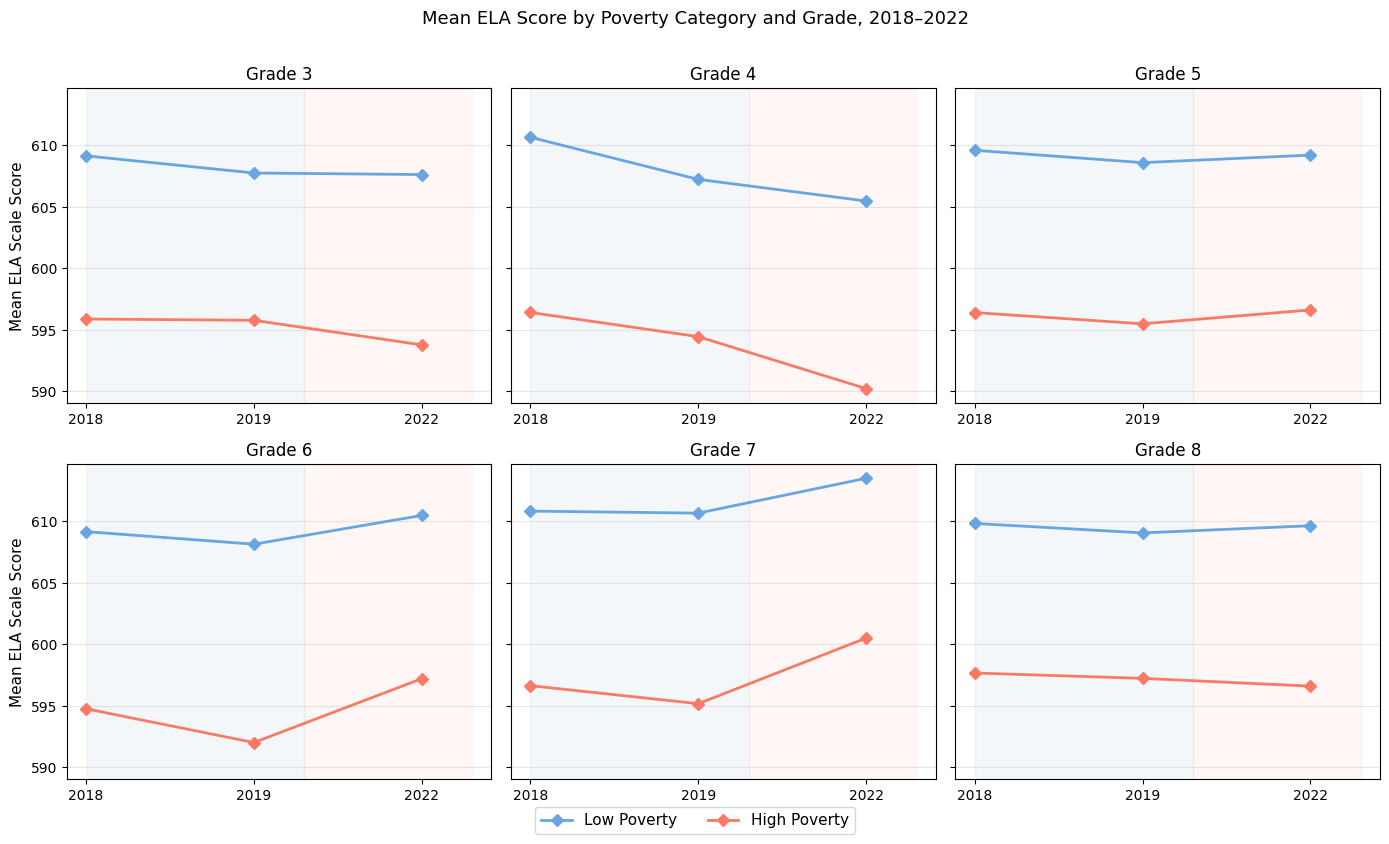

In [ ]:
# colors and labels for poverty categories
grades = ['3', '4', '5', '6', '7', '8']
colors = {0: "#68a5e1", 1: "#fb7a66"}
labels = {0: 'Low Poverty', 1: 'High Poverty'}
x = [0, 1, 2]
year_labels = ['2018', '2019', '2022']

# create subplots for each grade
# 2x3
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

# looping through grades and plotting for poverty category (high/low) where cutoff is 60%
for i, grade in enumerate(grades):
    ax = axes[i]
    grade_data = da_clean[da_clean['Grade'] == grade]

    # plot mean scores for low and high poverty categories
    for cat in [0, 1]:
        means = (
            grade_data[grade_data['Poverty_Category'] == cat]
            .groupby('Year')['mean_scale_score']
            .mean()
            .sort_index()
        )
        # line plot with markers for each year
        ax.plot(x, means.values, marker='D', linewidth=2, markersize=6.5,
                color=colors[cat], label=labels[cat])

    # pre covid period set from 2018 to roughly 2020
    ax.axvspan(0, 1.3, alpha=0.06, color='steelblue')
    # post covid period from 2020 to 2022
    ax.axvspan(1.3, 2.3, alpha=0.06, color='salmon')
    # year labels
    ax.set_xticks(x)
    ax.set_xticklabels(year_labels, fontsize=10)
    # title and grid for each subplot
    ax.set_title(f'Grade {grade}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

# y axis label on the left 
for row_ax in [axes[0], axes[3]]:
    row_ax.set_ylabel('Mean ELA Scale Score', fontsize=11)

# legend & title
handles, lab = axes[0].get_legend_handles_labels()
fig.legend(handles, lab, loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Mean ELA Score by Poverty Category and Grade, 2018–2022', fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

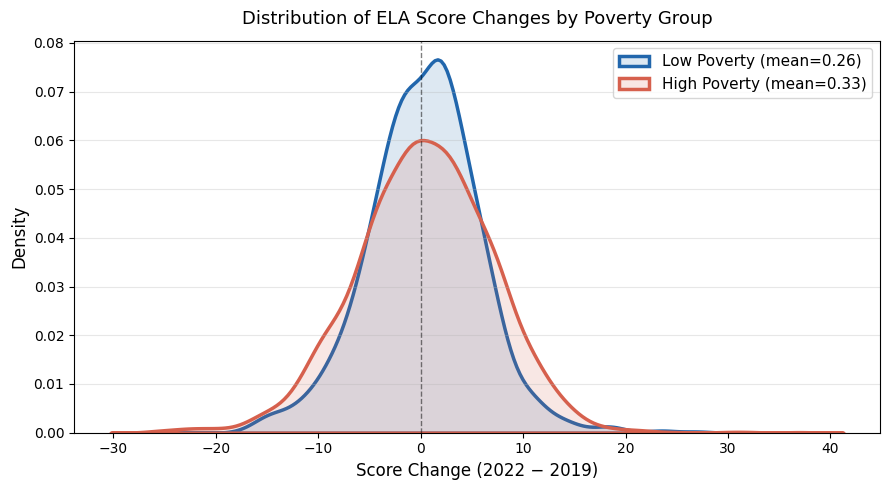

In [55]:
# compute delta score per school × grade
scores_2019 = (
    da_clean[da_clean['Year'] == 2019][['DBN', 'Grade', 'mean_scale_score', 'Poverty_Category']]
    .rename(columns={'mean_scale_score': 'score_2019'})
)
scores_2022 = (
    da_clean[da_clean['Year'] == 2022][['DBN', 'Grade', 'mean_scale_score']]
    .rename(columns={'mean_scale_score': 'score_2022'})
)

score_changes = scores_2019.merge(scores_2022, on=['DBN', 'Grade'], how='inner')
score_changes['delta'] = score_changes['score_2022'] - score_changes['score_2019']

# KDE plot
fig, ax = plt.subplots(figsize=(9, 5))

for cat, label, color in [(0, 'Low Poverty', '#2166ac'), (1, 'High Poverty', '#d6604d')]:
    sub = score_changes[score_changes['Poverty_Category'] == cat]['delta'].dropna()
    sns.kdeplot(sub, ax=ax, label=f'{label} (mean={sub.mean():.2f})',
                color=color, linewidth=2.5, fill=True, alpha=0.15)

ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Score Change (2022 − 2019)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of ELA Score Changes by Poverty Group', fontsize=13, pad=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [56]:
da_clean

,Report Category,DBN,school_name,Grade,Year,Student Category,number_tested,mean_scale_score,level_1_count,level_1_percentage,...,level_3_percentage,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty,Poverty_Category,School Level,poverty_clean,poverty_quartile
0,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2022,All Students,21,594.0,4.0,19.0,...,19.0,1.0,4.8,5.0,23.8,0.838,1,Elementary,83.8,Q3
1,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2022,All Students,30,596.0,6.0,20.0,...,16.7,5.0,16.7,10.0,33.3,0.838,1,Elementary,83.8,Q3
2,School,01M015,P.S. 015 ROBERTO CLEMENTE,5,2022,All Students,23,599.0,11.0,47.8,...,17.4,4.0,17.4,8.0,34.8,0.838,1,Elementary,83.8,Q3
4,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2019,All Students,27,606.0,1.0,3.7,...,66.7,1.0,3.7,19.0,70.4,0.845,1,Elementary,84.5,Q3
5,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2019,All Students,18,607.0,0.0,0.0,...,61.1,3.0,16.7,14.0,77.8,0.845,1,Elementary,84.5,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2019,All Students,109,595.0,42.0,38.5,...,23.9,6.0,5.5,32.0,29.4,0.949,1,Middle,94.9,Q4 (highest)
14461,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,8,2019,All Students,109,596.0,16.0,14.7,...,25.7,8.0,7.3,36.0,33.0,0.949,1,Middle,94.9,Q4 (highest)
14463,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,6,2018,All Students,111,595.0,37.0,33.3,...,23.4,11.0,9.9,37.0,33.3,0.915,1,Middle,91.5,Q3
14464,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2018,All Students,116,592.0,50.0,43.1,...,15.5,0.0,0.0,18.0,15.5,0.915,1,Middle,91.5,Q3


In [57]:
# district #

da_clean['school_district'] = da_clean['DBN'].str.extract(r'^(\d{2})')

In [58]:
da_clean

,Report Category,DBN,school_name,Grade,Year,Student Category,number_tested,mean_scale_score,level_1_count,level_1_percentage,...,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty,Poverty_Category,School Level,poverty_clean,poverty_quartile,school_district
0,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2022,All Students,21,594.0,4.0,19.0,...,1.0,4.8,5.0,23.8,0.838,1,Elementary,83.8,Q3,01
1,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2022,All Students,30,596.0,6.0,20.0,...,5.0,16.7,10.0,33.3,0.838,1,Elementary,83.8,Q3,01
2,School,01M015,P.S. 015 ROBERTO CLEMENTE,5,2022,All Students,23,599.0,11.0,47.8,...,4.0,17.4,8.0,34.8,0.838,1,Elementary,83.8,Q3,01
4,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2019,All Students,27,606.0,1.0,3.7,...,1.0,3.7,19.0,70.4,0.845,1,Elementary,84.5,Q3,01
5,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2019,All Students,18,607.0,0.0,0.0,...,3.0,16.7,14.0,77.8,0.845,1,Elementary,84.5,Q3,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2019,All Students,109,595.0,42.0,38.5,...,6.0,5.5,32.0,29.4,0.949,1,Middle,94.9,Q4 (highest),32
14461,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,8,2019,All Students,109,596.0,16.0,14.7,...,8.0,7.3,36.0,33.0,0.949,1,Middle,94.9,Q4 (highest),32
14463,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,6,2018,All Students,111,595.0,37.0,33.3,...,11.0,9.9,37.0,33.3,0.915,1,Middle,91.5,Q3,32
14464,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2018,All Students,116,592.0,50.0,43.1,...,0.0,0.0,18.0,15.5,0.915,1,Middle,91.5,Q3,32


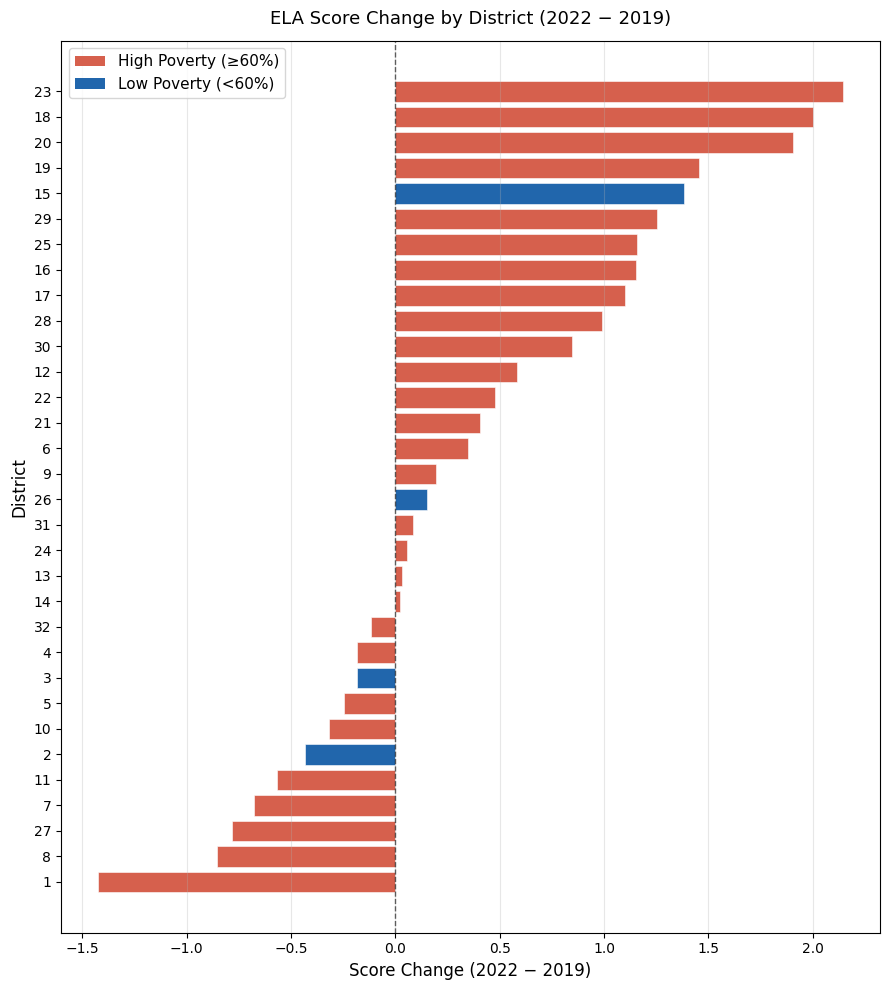

In [60]:
# build district stats from da_clean
da_clean['District'] = da_clean['DBN'].str[:2].astype(int)

dist_2019 = (
    da_clean[da_clean['Year'] == 2019]
    .groupby('District')
    .agg(poverty=('% Poverty', 'mean'), score_2019=('mean_scale_score', 'mean'))
    .reset_index()
)
dist_2022 = (
    da_clean[da_clean['Year'] == 2022]
    .groupby('District')['mean_scale_score']
    .mean()
    .reset_index()
    .rename(columns={'mean_scale_score': 'score_2022'})
)

district_stats = dist_2019.merge(dist_2022, on='District')
district_stats['delta'] = district_stats['score_2022'] - district_stats['score_2019']
district_stats = district_stats.sort_values('delta', ascending=True)

colors = ['#d6604d' if p >= 0.60 else '#2166ac' for p in district_stats['poverty']]

fig, ax = plt.subplots(figsize=(9, 10))

ax.barh(
    district_stats['District'].astype(str),
    district_stats['delta'],
    color=colors,
    edgecolor='white',
    linewidth=0.4
)

ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Score Change (2022 − 2019)', fontsize=12)
ax.set_ylabel('District', fontsize=12)
ax.set_title('ELA Score Change by District (2022 − 2019)', fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d6604d', label='High Poverty (≥60%)'),
    Patch(facecolor='#2166ac', label='Low Poverty (<60%)')
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()
